In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Set Paths (Using your specific directory structure)
train_dir = '/content/drive/MyDrive/Pneumonia Disease/dataset/train'
test_dir = '/content/drive/MyDrive/Pneumonia Disease/dataset/test'
val_dir = '/content/drive/MyDrive/Pneumonia Disease/dataset/val'

# 3. Enable Mixed Precision (Crucial for Free Colab Tier speed)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print("Environment Setup Complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment Setup Complete.


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64

# Data Augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=10 # Added slight rotation for medical imaging robustness
)

# Only preprocessing for Validation/Test
test_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_gen = test_val_datagen.flow_from_directory(
    val_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

test_gen = test_val_datagen.flow_from_directory(
    test_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

# Compute weights to handle class imbalance (Normal vs Pneumonia)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Class Weights Applied: {class_weights_dict}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class Weights Applied: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
# Load DenseNet121 without the top layer
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze base for Phase 1

# Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Higher dropout to fight overfitting
# Ensure the final layer is float32 for numeric stability in mixed precision
prediction = Dense(1, activation='sigmoid', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=prediction)

# Analysis: Show model structure
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks to save time and compute
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

# Define how many steps to take.
# Total images / Batch size = steps. 50 is a good speed for Colab.
SPE = 50

print("Starting Fast Phase 1...")

# We removed 'workers' and 'use_multiprocessing' to fix the TypeError
history_p1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=SPE,
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler, early_stop]
)

Starting Fast Phase 1...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1365s 27s/step - accuracy: 0.7750 - loss: 0.4567 - val_accuracy: 0.8750 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 2/10
32/50 ━━━━━━━━━━━━━━━━━━━━ 3:11 11s/step - accuracy: 0.9016 - loss: 0.2306

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 331s 7s/step - accuracy: 0.9061 - loss: 0.2231 - val_accuracy: 0.9375 - val_loss: 0.2723 - learning_rate: 0.0010
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 394s 8s/step - accuracy: 0.9288 - loss: 0.1773 - val_accuracy: 0.9375 - val_loss: 0.2564 - learning_rate: 0.0010
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9235 - loss: 0.1833 - val_accuracy: 0.9375 - val_loss: 0.2288 - learning_rate: 0.0010
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9374 - loss: 0.1528 - val_accuracy: 0.9375 - val_loss: 0.3236 - learning_rate: 0.0010
Epoch 6/10
32/50 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9264 - loss: 0.1682
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9281 - loss: 0.1686 - val_accuracy: 0.8750 - val_loss: 0.2431 - learning_rate: 0.0010
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9430 - loss: 0.1357 - val_accuracy: 0.9375 -

In [ ]:
print("Starting Phase 2: Fine-Tuning...")
base_model.trainable = True

# We freeze the first 300 layers and unfreeze the rest
# DenseNet121 has about 427 layers total
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Use a very low learning rate so we don't destroy pre-trained weights
model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

history_p2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler, early_stop]
)

# Save the final improved model
model.save('/content/drive/MyDrive/Pneumonia Disease/pneumonia_densenet_v2.keras')

Starting Phase 2: Fine-Tuning...
Epoch 1/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9054 - loss: 0.4148 - val_accuracy: 0.9375 - val_loss: 0.2062 - learning_rate: 1.0000e-05
Epoch 2/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9535 - loss: 0.1437 - val_accuracy: 0.9375 - val_loss: 0.1869 - learning_rate: 1.0000e-05
Epoch 3/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9467 - loss: 0.1399 - val_accuracy: 0.9375 - val_loss: 0.1567 - learning_rate: 1.0000e-05
Epoch 4/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9496 - loss: 0.1294 - val_accuracy: 0.9375 - val_loss: 0.1468 - learning_rate: 1.0000e-05
Epoch 5/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9478 - loss: 0.1511 - val_accuracy: 0.9375 - val_loss: 0.1342 - learning_rate: 1.0000e-05
Epoch 6/12
82/82 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9493 - loss: 0.1320 - val_accuracy: 0.9375 - val_loss: 0.1312 - learning_rate: 1.0000e-05
Epoch 7/12
82/82 ━━━━━━━━━━━━━━━━━━━━

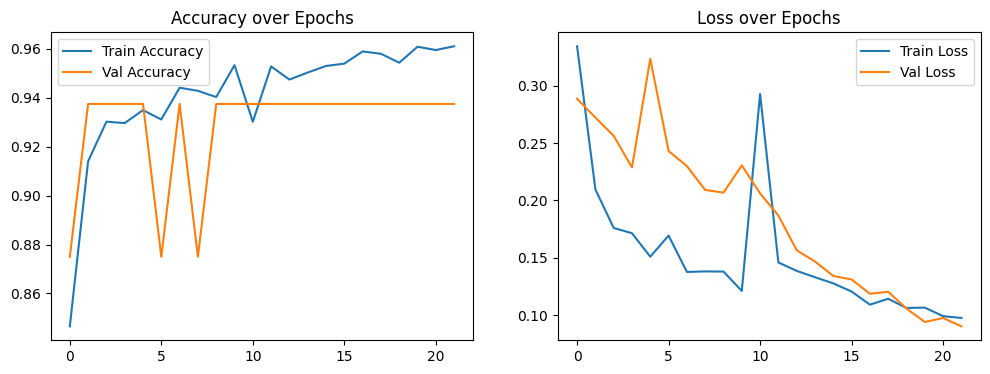


--- Generating Detailed Inference Report ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 350s 37s/step
              precision    recall  f1-score   support

      Normal       0.90      0.87      0.89       234
   Pneumonia       0.92      0.94      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.91      0.92      0.91       624



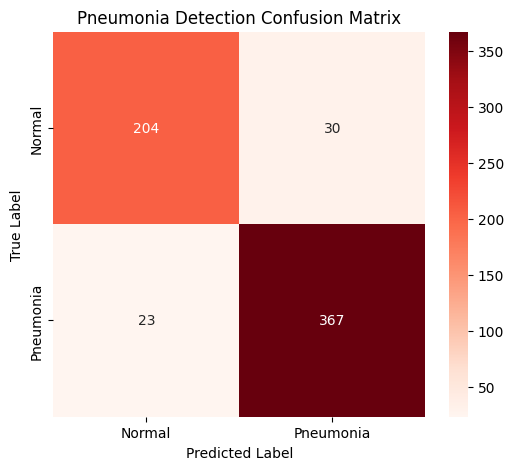

In [ ]:
# 1. Plot Training History
acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# 2. Detailed Inference Testing
print("\n--- Generating Detailed Inference Report ---")
test_gen.reset()
Y_pred = model.predict(test_gen)
y_pred = (Y_pred > 0.5).astype(int)

# Classification Report
print(classification_report(test_gen.classes, y_pred, target_names=['Normal', 'Pneumonia']))

# Confusion Matrix Heatmap
cm = confusion_matrix(test_gen.classes, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Pneumonia Detection Confusion Matrix')
plt.show()

In [ ]:
# save it as a h5 file

import tensorflow as tf

from keras.models import load_model

# model.save('model_vgg16.h5')
model.save('/content/drive/My Drive/Pneumonia Disease/model_vgg16-2.h5')
# model.save("/content/drive/My Drive/Pneumonia Disease/pneumonia_saved_model")
model.save("/content/drive/My Drive/Pneumonia Disease/modepneumonia_densenet_v2.keraspneumonia_densenet_v2.kerasl_vgg16.keras")


2
